# <font color='blue'> Module 4: Statistical Tests </font>

Two major applications of statistics are:
- **Hypothesis Testing** : Comparing the data against two theories.
- **Parameter Estimating** : Estimating the parameters given a particular theory.

# <font color='orange'> Hypothesis Testing </font>

The objective of statistical test theory is to make a formal decision about the validity of a hypothesis ($H_0$, the null hypothesis) based on observed experimental data.

## <font color='orange'> Fundamental Components </font>

* **Test Statistic ($t$):** Since observed data often consist of multidimensional variables $\mathbf{x} = (x_1, \dots, x_n)$, we reduce this data to a single scalar value $t(\mathbf{x})$. This simplifies the decision-making process while aiming to preserve the discriminating power between hypotheses.
* **PDFs and Separation:** Each hypothesis (e.g., $H_0$ and the alternative hypothesis $H_1$) implies a unique probability density function (PDF) for the test statistic, denoted as $g(t|H_0)$ and $g(t|H_1)$.
* **Critical Region and $t_{\text{cut}}$:** We define a "critical region" (e.g., $t > t_{\text{cut}}$) where the observed data is sufficiently unlikely under $H_0$ that we choose to reject it. 



## <font color='orange'> Performance Metrics </font>

The choice of the decision boundary, $t_{\text{cut}}$, dictates the performance of the statistical test through two primary error types:

1.  **Significance Level ($\alpha$):** Also known as the probability of a Type I error, this is the probability of rejecting $H_0$ when it is actually true.
    $$\alpha = \int_{t_{\text{cut}}}^{\infty} g(t|H_0) dt$$

2.  **Error of the Second Kind ($\beta$):** Also known as the probability of a Type II error, this is the probability of accepting $H_0$ when the alternative hypothesis $H_1$ is actually true.
    $$\beta = \int_{-\infty}^{t_{\text{cut}}} g(t|H_1) dt$$

---

## <font color='orange'> Glossary of Terms </font>

| Term | Definition |
| :--- | :--- |
| **Null Hypothesis ($H_0$)** | The baseline hypothesis to be tested, often representing "no effect" or the standard model. |
| **Alternative Hypothesis ($H_1$)** | The hypothesis that competes with the null, typically representing the phenomenon one hopes to discover. |
| **Type I Error ($\alpha$)** | The "False Positive" rate; incorrectly rejecting a true null hypothesis. |
| **Type II Error ($\beta$)** | The "False Negative" rate; incorrectly failing to reject a false null hypothesis. |
| **Power of the Test ($1 - \beta$)** | The probability that the test correctly rejects a false null hypothesis (the ability to detect an effect when it exists). |
| **Decision Boundary ($t_{\text{cut}}$)** | The threshold value used to partition the space of the test statistic into rejection and acceptance regions. |

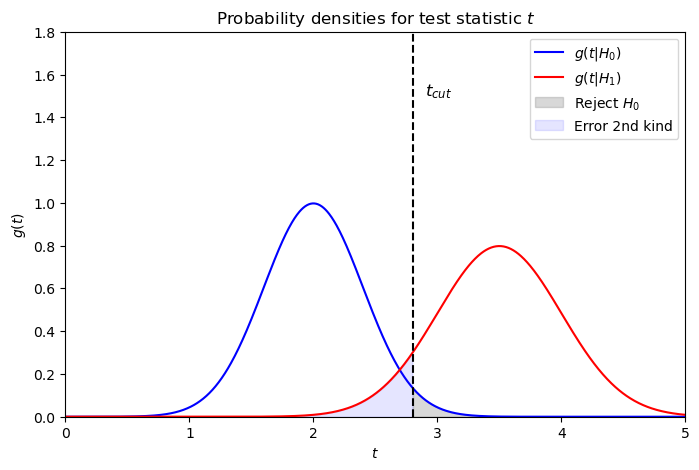

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define parameters for the two hypotheses distributions
mu0, sigma0 = 2.0, 0.4
mu1, sigma1 = 3.5, 0.5
t_cut = 2.8

# Generate t values
t = np.linspace(0, 5, 1000)

# Calculate PDFs
pdf0 = norm.pdf(t, mu0, sigma0)
pdf1 = norm.pdf(t, mu1, sigma1)

# Plotting
plt.figure(figsize=(8, 5))
plt.plot(t, pdf0, label=r'$g(t|H_0)$', color='blue')
plt.plot(t, pdf1, label=r'$g(t|H_1)$', color='red')

# Fill the regions
plt.fill_between(t, pdf0, where=(t > t_cut), color='gray', alpha=0.3, label='Reject $H_0$')
plt.fill_between(t, pdf1, where=(t < t_cut), color='blue', alpha=0.1, label='Error 2nd kind')

# Add decision boundary
plt.axvline(t_cut, color='black', linestyle='--')
plt.text(t_cut + 0.1, 1.5, '$t_{cut}$', fontsize=12)

# Labels and styling
plt.xlabel('$t$')
plt.ylabel('$g(t)$')
plt.ylim(0, 1.8)
plt.xlim(0, 5)
plt.legend()
plt.title('Probability densities for test statistic $t$')
plt.show()

# <font color='blue'> The Neyman-Pearson Lemma </font>

The **Neyman-Pearson lemma** is a fundamental theorem in statistical hypothesis testing that provides a rigorous method for constructing the most powerful test when comparing two simple hypotheses.

## <font color='orange'> Core Concept </font>
When testing a null hypothesis ($H_0$) against an alternative hypothesis ($H_1$), the goal is to maximize the probability of rejecting $H_0$ when it is false (the power of the test, $1-\beta$) while maintaining a fixed significance level ($\alpha$) for Type I errors. The lemma mathematically proves that the most powerful test is constructed using the **likelihood ratio**.



## <font color='orange'> The Likelihood Ratio Test </font>
The lemma states that the optimal decision boundary is determined by the ratio of the likelihoods of the observed data ($\mathbf{x}$) under the two competing hypotheses:

$$\lambda(\mathbf{x}) = \frac{L(\mathbf{x} | H_0)}{L(\mathbf{x} | H_1)}$$

According to the lemma, the **critical region** (the set of data points where you reject $H_0$) consists of all values where the likelihood ratio exceeds a specific threshold ($k$):

$$\frac{L(\mathbf{x} | H_0)}{L(\mathbf{x} | H_1)} > k$$

## <font color='orange'> Significance and Application </font>
* **Optimality:** This lemma provides a mathematical guarantee that no other test can achieve a higher power than the likelihood ratio test for a given significance level.
* **Simplification:** It justifies the standard practice in particle physics of reducing multidimensional experimental data into a single, manageable scalar value—the test statistic ($t$)—without sacrificing discriminating power.
* **Practical Utility:** In research, this result forms the foundation for defining test statistics (often expressed as $t = -2 \ln \lambda$), which are essential for tasks like discovering new particles or excluding specific physical models.

In summary, the Neyman-Pearson lemma provides the theoretical framework required to partition experimental data into "acceptance" and "rejection" regions as efficiently as possible.

## <font color='orange'> Limitation </font>
$$t(\mathbf{x}) = \frac{L(\mathbf{x} | H_0)}{L(\mathbf{x} | H_1)}$$
The likelihood ratio $t(\mathbf{x})$, requires both functions $L(\mathbf{x} | H_0)$ and $L(\mathbf{x} | H_1)$. MC method can be used to determine these functions but if there are $M$ bins and $n$ components, $M^{n}$ components need to be evaluated.

# <font color='blue'> Building Test Statistics </font>

The question is can we build a statistical test that gives us a simple score telling whether $H_0$ or $H_1$ is true.

# <font color='orange'> Linear Tests: Fisher Linear Discriminant (FLD) </font>

The Fisher Linear Discriminant is a classic technique used to project high-dimensional data onto a single dimension (a line) such that the separation between two classes is maximized. Glen Cowan discusses this as a specific type of **linear test statistic**.

Instead of constructing a complex, non-linear function, we define the test statistic $t$ as a linear combination of the input variables $\mathbf{x} = (x_1, x_2, \dots, x_n)$:

$$t(\mathbf{x}) = \mathbf{w}^T \mathbf{x} = \sum_{i=1}^{n} w_i x_i$$

The goal is to find the optimal weight vector $\mathbf{w}$ that best distinguishes, for example, "signal" ($H_1$) from "background" ($H_0$).

---

### <font color='orange'> The Construction Principle </font>
To find the best $\mathbf{w}$, we want the projected data to satisfy two conditions simultaneously:

1.  **Maximize the distance between class means:** We want the difference between the mean of $t$ for signal ($\mu_s$) and the mean of $t$ for background ($\mu_b$) to be as large as possible.
2.  **Minimize the variance within each class:** We want the data points of each class to be tightly clustered around their respective means, rather than spread out.

These two requirements are captured by the **Fisher criterion**, $J(\mathbf{w})$:

$$J(\mathbf{w}) = \frac{(\mu_s - \mu_b)^2}{\sigma_s^2 + \sigma_b^2}$$

where $\sigma^2$ is the variance of the projected data for each class.



---

### <font color='orange'> Mathematically Solving for the Weights </font>
By maximizing this ratio with respect to $\mathbf{w}$, you arrive at a solution involving the mean vectors and the within-class covariance matrices ($S_w$):

$$\mathbf{w} \propto S_w^{-1} (\boldsymbol{\mu}_s - \boldsymbol{\mu}_b)$$

In simpler terms, the optimal weights are determined by:
* The difference between the average feature values of the two classes.
* The inverse of the covariance matrix, which accounts for the correlations between your variables and "stretches" the space to account for the shape of the noise.

#### The W is determined using MC or training data.

---

###  <font color='orange'> Why is it a "Linear Test Statistic"? </font>
It is called a "linear test statistic" because the resulting value $t$ is a simple weighted sum. If you have 10 input variables, the Fisher discriminant effectively collapses all of them into one variable. You then apply a threshold to $t$ to decide whether to accept or reject the null hypothesis.

---

## Advantages and Limitations

* **Simplicity:** It is computationally efficient and requires estimating only the means and the covariance matrix. It does not require massive amounts of Monte Carlo training data compared to complex Neural Networks.
* **Optimality:** If the distributions of your variables for both classes are multivariate Gaussian and share the same covariance matrix, the Fisher discriminant is actually the *optimal* test statistic—it is equivalent to the likelihood ratio.
* **Limitations:** If the optimal separation boundary between your classes is non-linear (e.g., the signal is "inside" a ring of background), a linear test statistic will perform poorly. This is why in modern particle physics, while the Fisher discriminant is a great starting point, we often move toward **Boosted Decision Trees (BDTs)** or **Neural Networks** to capture non-linear correlations.

### <font color='violet'> A Demonstration of Fisher Linear Discriminant (FLD) with 2D Datasets </font>

When working with a larger set, the manual process remains identical, but the arithmetic requires more care. Here is the recommended workflow to handle the increased volume:

1.  **Mean Vectors**: Calculate $\mathbf{m}_1 = \frac{1}{n_1} \sum \mathbf{x}_i$ and $\mathbf{m}_2 = \frac{1}{n_2} \sum \mathbf{x}_i$.
2.  **Scatter Matrices ($S_1$ and $S_2$)**: 
    * For each class, compute the $2 \times 2$ matrix $S_i = \sum (\mathbf{x} - \mathbf{m}_i)(\mathbf{x} - \mathbf{m}_i)^T$.
    * **Tip**: This is a summation of outer products. For example, if a point is $\mathbf{x} = [x, y]^T$ and the mean is $\mathbf{m} = [\mu_x, \mu_y]^T$, the contribution to the scatter matrix is:
    $$\begin{bmatrix} (x-\mu_x)^2 & (x-\mu_x)(y-\mu_y) \\ (x-\mu_x)(y-\mu_y) & (y-\mu_y)^2 \end{bmatrix}$$
3.  **Compute $S_W$**: Simply sum the two matrices: $S_W = S_1 + S_2$.
4.  **Solve**: $\mathbf{w} = S_W^{-1}(\mathbf{m}_2 - \mathbf{m}_1)$. Since $S_W$ is a $2 \times 2$ matrix, you can use the standard determinant formula for the inverse:
    $$\begin{bmatrix} a & b \\ c & d \end{bmatrix}^{-1} = \frac{1}{ad-bc} \begin{bmatrix} d & -b \\ -c & a \end{bmatrix}$$



---

#### Why this is better for practice:

* **Statistical Significance**: With more points per class, the mean vectors and the variance (the diagonal elements of $S_i$) become more statistically meaningful.
* **Sensitivity**: You will observe how the orientation of $\mathbf{w}$ is sensitive not just to the difference in means, but to the covariance (the off-diagonal elements in $S_i$) of the clusters.
* **Verification**: If you plot these, you will see that $\mathcal{C}_1$ and $\mathcal{C}_2$ have a slight diagonal "stretch." FLD will automatically account for this orientation, whereas a simpler approach might fail.

Mean Vectors are:
m1 = [2.4 2.8]
m2 = [7.6 7.4]
The Scatter Matrices are:
S1 = [[ 5.2 -1.6]
 [-1.6  2.8]]
 
S2 = [[5.2 1.8]
 [1.8 5.2]]
Sw is given by: 
[[10.4  0.2]
 [ 0.2  8. ]]
w = [0.48917749 0.56277056]
arr1_w = [2.92022645 2.82153093 4.33099192 4.23229639 4.13360086]
arr2_w = [ 8.46459278 10.63008874 10.53139321 12.0408542  11.18742818]
10.827479792135149


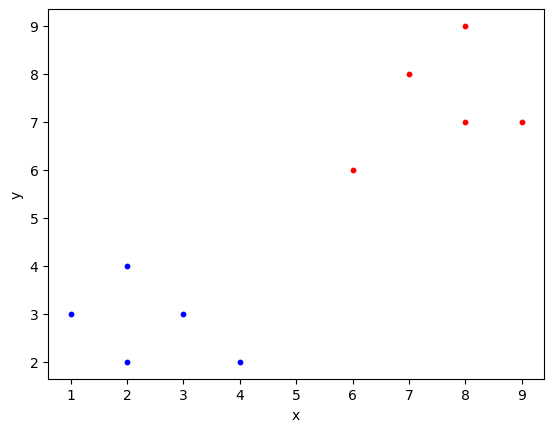

In [56]:
import numpy as np

# dataset
class_1 = [(1,3), (2,2), (2,4), (3,3), (4,2)]
class_2 = [(6,6), (7,8), (8,7), (8,9), (9,7)]

#convert to numpy array
arr1 = np.array(class_1)
arr2 = np.array(class_2)

#plot the datasets
plt.scatter(arr1[:, 0], arr1[:,1], c='blue', s=10, label='Class 1')
plt.scatter(arr2[:, 0], arr2[:,1], c='red', s=10, label='Class 2')
plt.xlabel('x')
plt.ylabel('y')

# determining the mean vectors, m = 1\N \sum(x_i)
m1 = np.mean(arr1, axis=0)
m2 = np.mean(arr2, axis=0)

print("Mean Vectors are:")
print(f"m1 = {m1}")
print(f"m2 = {m2}")

# determining scatter matrices
deviations1 = arr1-m1
S1 = deviations1.T @ deviations1

deviations2 = arr2-m2
S2 = deviations2.T @ deviations2

print("="*60)
print("The Scatter Matrices are:")
print(f"S1 = {S1}")
print(" ")
print(f"S2 = {S2}")
print("="*60)

# calculate Sw = S1 + S2
print("Sw is given by: ")
Sw = S1+S2
print(Sw)
print("="*60)

# calculating w
w = np.linalg.inv(Sw)@(m2 - m1)
print(f"w = {w}")
print("="*60)

# apply transformation
w_normalized = w / np.linalg.norm(w)

arr1_w = arr1 @ w_normalized.T
print(f"arr1_w = {arr1_w}")

arr2_w = arr2 @ w_normalized.T
print(f"arr2_w = {arr2_w}")

# test for a random point
test = np.array([5,10] @ w_normalized.T)
print(test)

# <font color='orange'> Non-Linear Test: Neural Networks </font>

### From Fisher Linear Discriminant to Perceptrons

Neural networks are a class of machine learning models inspired by the structure and function of biological brains. At their core, they are sophisticated function approximators designed to map input data to desired outputs by learning patterns through hierarchical data representations.

---

## <font color='orange'> 1. The Foundation: Fisher Linear Discriminant (FLD) </font>

To understand neural networks, we must look at the **Fisher Linear Discriminant**. FLD is a dimensionality reduction technique used in classification. It finds a projection vector $w$ that maximizes the class separability by maximizing the ratio of between-class variance to within-class variance.

### <font color='orange'> The Objective Function </font>
The goal is to find $w$ that maximizes the Fisher criterion $J(w)$:
$$J(w) = \frac{w^T S_B w}{w^T S_W w}$$

Where:
* $S_B$: Between-class scatter matrix.
* $S_W$: Within-class scatter matrix.

**The Correlation:** FLD is essentially a **single-layer linear classifier**. It performs a linear transformation of the input followed by a thresholding decision. This is the simplest possible form of a "neuron"—a linear combination of inputs that determines a decision boundary.

---

## <font color='orange'> 2. The Building Block: Single-Layer Perceptron </font>

The **Perceptron** is the basic unit of a neural network. It extends the concept of linear classification (like FLD) by introducing a non-linear activation function.

### <font color='orange'> The Mechanism </font>
A perceptron takes a vector of inputs $x$, applies weights $w$, adds a bias $b$, and passes the result through an activation function $\sigma$:

$$z = w^T x + b$$
$$\hat{y} = \sigma(z)$$

Commonly, for a simple binary perceptron, $\sigma$ is the Heaviside step function:
$$\sigma(z) = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{if } z < 0 \end{cases}$$



---

## <font color='orange'> 3. Scaling to Neural Networks </font>

A neural network is constructed by stacking these perceptrons into layers. While a single-layer perceptron can only solve linearly separable problems, multi-layer networks (Multi-Layer Perceptrons - MLP) use non-linear activation functions (like ReLU or Sigmoid) to model complex, non-linear decision boundaries.

### <font color='orange'> Forward Propagation </font>
For a network with $L$ layers, the activation at layer $l$ is calculated as:
$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}$$
$$a^{(l)} = \sigma(z^{(l)})$$

### <font color='orange'> Learning via Backpropagation </font>
To train these networks, we define a Loss Function (e.g., Mean Squared Error or Cross-Entropy) and minimize it using **Gradient Descent**. We compute the gradient of the loss $L$ with respect to the weights using the Chain Rule:

$$\frac{\partial L}{\partial w^{(l)}} = \frac{\partial L}{\partial a^{(l)}} \cdot \frac{\partial a^{(l)}}{\partial z^{(l)}} \cdot \frac{\partial z^{(l)}}{\partial w^{(l)}}$$

This iterative update rule allows the network to "learn" the optimal feature representations, essentially generalizing the logic of the Fisher Linear Discriminant across multiple levels of abstraction.

---

## <font color='orange'> Summary Comparison </font>

| Concept | Nature | Function |
| :--- | :--- | :--- |
| **Fisher LDA** | Linear | Maximize class separability via linear projection. |
| **Perceptron** | Linear/Non-linear | Maps input to output via weighted sum and activation. |
| **Neural Network** | Deeply Non-linear | Hierarchical feature extraction via stacked layers. |

# <font color='blue'> Goodness of Fit Tests </font>

**Goodness of fit** tests refer to the compatibility of the observed data with the **null hypothesis**. A goodness of fit test gives **p-value** (aka **observed significance level** or **confidence level**) which is the probability of observing the data as compatible or less compatible with the null hypothesis.

## <font color='orange'> Pearson's ${\chi}^{2}$ Test </font>

Pearson's Chi-squared test is a statistical hypothesis test used to determine if there is a significant difference between the observed frequencies of data and the frequencies that would be expected under a hypothesized distribution. It is widely used to test the "goodness-of-fit" of a model or the independence between two categorical variables.

---

### <font color='orange'> The Core Concept </font>
The test evaluates how well an observed set of data points, categorized into $k$ bins, matches the expected counts derived from a theoretical probability distribution. The test statistic, denoted as $\chi^2$, is calculated by summing the squared differences between observed ($O_i$) and expected ($E_i$) frequencies, normalized by the expected frequencies:

$$\chi^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$



### <font color='orange'> Implementation Steps </font>

1.  **Define Hypotheses**:
    * **Null Hypothesis ($H_0$)**: The observed data follows the theoretical distribution.
    * **Alternative Hypothesis ($H_1$)**: The observed data does not follow the theoretical distribution.
2.  **Calculate Expected Frequencies**: Based on the null hypothesis, calculate the number of events expected in each bin ($E_i$).
3.  **Compute the Statistic**: Calculate the $\chi^2$ value using the formula above.
4.  **Determine Degrees of Freedom ($dof$)**: The $dof$ is typically defined as $k - 1 - m$, where $k$ is the number of bins and $m$ is the number of parameters estimated from the data.
5.  **Calculate the p-value**: Compare the computed $\chi^2$ against the $\chi^2$ distribution for the given $dof$. If the p-value is below a chosen significance level (e.g., 0.05), $H_0$ is rejected.

---

### <font color='orange'> Assumptions and Requirements </font>
* **Independence**: Observations must be independent of one another.
* **Sample Size**: Each bin should typically have an expected frequency of at least 5. If counts are too low, the $\chi^2$ approximation becomes inaccurate.
* **Categorical Data**: The data must be in the form of frequencies (counts) rather than continuous measurements.

### <font color='orange'> Significance in Particle Physics </font>
In the context of the statistical tests discussed by Glen Cowan, the $\chi^2$ test serves as a common example of a test statistic used to evaluate goodness-of-fit. When data is grouped into bins, the likelihood ratio test often asymptotically approaches the $\chi^2$ distribution, providing a robust way to quantify how well an experimental model describes the observed data.

---

### <font color='orange'> Glossary of Terms </font>

| Term | Definition |
| :--- | :--- |
| **Observed Frequency ($O_i$)** | The actual count of events recorded in bin $i$. |
| **Expected Frequency ($E_i$)** | The count of events predicted by the null hypothesis for bin $i$. |
| **Degrees of Freedom ($dof$)** | The number of values in the final calculation that are free to vary; essential for determining the correct distribution. |
| **Goodness-of-Fit** | A measure of how well the theoretical distribution describes the actual observed frequency distribution. |

## <font color='violet'> Example </font>

Degrees of freedom: 47
Chi-Squared Statistic: 26.6968
P-value: 0.9961


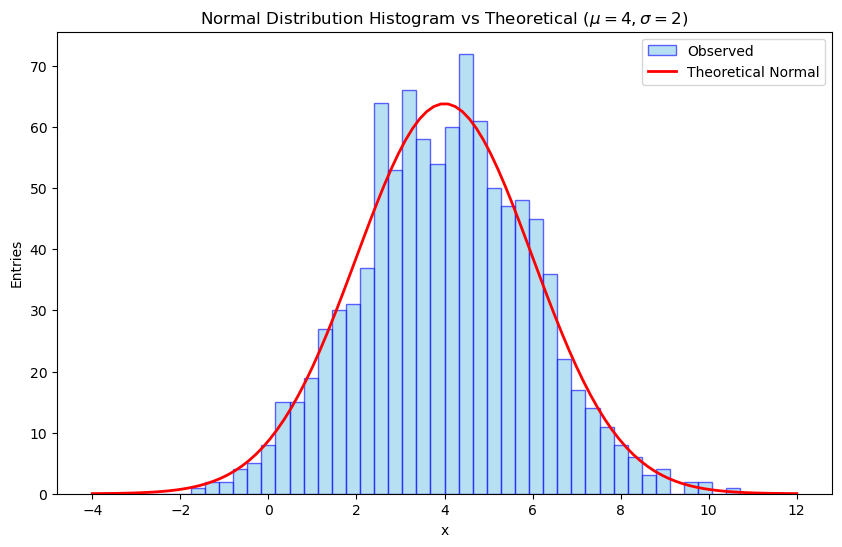

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Setup the data and parameters
# We use 1000 samples from a normal distribution
mu, sigma = 4, 2
n_samples = 1000
data = np.random.normal(mu, sigma, n_samples)

# 2. Define bins
# We use 50 bins between -4 and 12
bins = np.linspace(-4, 12, 51)
observed_counts, bin_edges = np.histogram(data, bins=bins)

# 3. Calculate expected frequencies
# We use the CDF of the normal distribution to find the probability of falling into each bin
cdf_values = stats.norm.cdf(bin_edges, mu, sigma)
probabilities = np.diff(cdf_values)
expected_counts = probabilities * n_samples

# 4. Correct for floating-point discrepancies
# SciPy requires the sum of observed and expected frequencies to be identical
expected_counts = expected_counts * (np.sum(observed_counts) / np.sum(expected_counts))

# 5. Perform Chi-Squared test
# We use ddof=2 because we are comparing against a normal distribution 
# where we essentially define the parameters (or if estimated from data)
chi2_stat, p_value = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)

print(f"Degrees of freedom: {len(bin_edges) - 1 - 1- 2}")
print(f"Chi-Squared Statistic: {chi2_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# 6. Visualization
plt.figure(figsize=(10, 6))
plt.hist(data, bins=bins, color='skyblue', edgecolor='blue', alpha=0.6, label='Observed')

# Plot the theoretical distribution for comparison
x_axis = np.linspace(-4, 12, 100)
plt.plot(x_axis, stats.norm.pdf(x_axis, mu, sigma) * n_samples * (bins[1]-bins[0]), 
         color='red', lw=2, label='Theoretical Normal')

plt.title(r'Normal Distribution Histogram vs Theoretical ($\mu = 4, \sigma = 2$)')
plt.xlabel('x')
plt.ylabel('Entries')
plt.legend()
plt.show()